# Real Data Reconstruction

Converts `aligned_center_points.mat` (x, y pixel coordinates from video) into a
`cosserat_simulation_data_Verlet.mat`-compatible format with all 6 state groups:

| Group | Symbol | Size | Description |
|-------|--------|------|-------------|
| 1 | x | N+1 | Horizontal position (m) |
| 2 | y | N+1 | Vertical position (m) |
| 3 | θ | N | Segment tangent angle (rad) |
| 4 | p_x | N+1 | Linear momentum x = ρA · ẋ |
| 5 | p_y | N+1 | Linear momentum y = ρA · ẏ |
| 6 | p_θ | N | Angular momentum = ρI · θ̇ |

**Pipeline:**
1. Load raw pixel data
2. Pixel-to-meter calibration
3. Downsample 100 → N+1 nodes to match simulation
4. Compute θ geometrically from (x, y)
5. Smooth all states temporally (Savitzky-Golay)
6. Compute time derivatives (ẋ, ẏ, θ̇) by finite difference on smoothed data
7. Compute conjugate momenta (p_x, p_y, p_θ)
8. Enforce boundary conditions (clamped base)
9. Sanity checks and visualisation
10. Save as `.mat`

In [1]:
# !pip install scipy
# !pip install matplotlib
# !pip install numpy

## Step 1 — Configuration

Set all physical parameters and calibration constants here.
Everything downstream reads from this cell.

In [641]:
import numpy as np
import scipy.io as sio
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# ── Figure defaults ──────────────────────────────────────────────────────────
import matplotlib
matplotlib.rcParams['figure.dpi']     = 100
matplotlib.rcParams['figure.figsize'] = (8, 4)
import os

# ── Paths ──────────────────────────────────────────────────────────────────
# INPUT_MAT   = '../Data/Real_data/aligned_center_points_live.mat'
# INPUT_MAT   = '../aligned_center_points_live.mat'
# INPUT_MAT   = '../Data/Real_data/centerline_data.mat'
# INPUT_MAT   = '../Data/Real_data/centerline_data_new.mat'
# INPUT_MAT   = '../Data/Real_data/centerline_data_m.mat'
# INPUT_TXT   = '../Data/Real_data/centerline_data_new.txt'  # read .txt directly
INPUT_TXT   = 'centerline_data.txt'  # read .txt directly



OUTPUT_MAT      = 'cosserat_real_data.mat'
OUTPUT_MAT_DOT  = 'cosserat_real_data_dot.mat'

# ── Rod discretisation ─────────────────────────────────────────────────────
N   = 25          # number of segments  → N+1 = 26 nodes
L0  = 0.38        # real rod physical length (m) — measured directly

# ── Physical parameters ────────────────────────────────────────────────────
rho   = 1000.0                    # density (kg/m³)
r     = 1e-2                      # cross-section radius (m)
a     = 0.02                      # cross-section width (m) — for square rod
A     = np.pi * r**2 / 4          # cross-sectional area (m²)
# A     = a**2              # cross-sectional area (m²) — corrected for square rod
I     = A**2 / (4 * np.pi)        # second moment of area (m⁴)
# I     = a**2 / 12                   # second moment of area (m⁴) — corrected for square rod
E     = 3e6                       # Young's modulus (Pa)
G     = E / (2 * (1 + 0.5))       # shear modulus (Pa)

# ── Video / calibration ────────────────────────────────────────────────────
FPS           = 194.0             # camera frame rate (Hz)
# N_VIDEO_PTS is auto-detected from the .txt file in the load cell
# (100 for old ros_centerline.py data, 25 for ros_centerline_2.py data)

# Pixel-to-metre scale factor.
# Node 0 is the clamp (zero variance); node ordering is clamp→tip.
# Median arc length across all frames = 374.5 px; L0 = 0.3 m → 1248.2 px/m
PIXELS_PER_METRE = None#1248.2

# Clamp pixel position — node 0 of the raw data (fixed point, zero variance).
CLAMP_PX = np.array([570, 1.0])   # [x_px, y_px]

# ── Frame trimming ─────────────────────────────────────────────────────────
# Frames to drop from the START of the recording (initial transient).
# At FPS=194:  60 frames ≈ 0.31 s,  120 frames ≈ 0.62 s.  Set 0 to keep all.
TRIM_FRAMES = 0

# ── Coordinate orientation ─────────────────────────────────────────────────
ROTATE_TO_HORIZONTAL = False

# ── Smoothing (legacy — kept for reference, superseded by GP) ──────────────
SG_WINDOW  = 21    # Savitzky-Golay window (frames, must be odd > SG_POLY)
SG_POLY    = 3     # polynomial order

# ── GP configuration ───────────────────────────────────────────────────────
# N_TRAIN_PTS : how many spatial points (columns) to train GPs on.
#               Set to N_VIDEO_PTS to use all raw video points.
#               Assigned in the load cell once N_VIDEO_PTS is known.
# N_TRAIN_PTS is set in the load cell — do not hardcode here.

# GP_STRIDE   : use every GP_STRIDE-th frame for GP training (speeds up fitgp).
#               1 = use all frames; increase if training is too slow.
GP_STRIDE   = 2

# N_DENSE     : number of spatial query points used to compute θ accurately.
#               Dense query → smooth tangent angle; subsample to N segments.
N_DENSE     = 500

print('Configuration loaded.')
print(f'  N = {N}  (nodes = {N+1})')
print(f'  L0 = {L0} m  (real rod physical length)')
print(f'  rho = {rho}  A = {A:.4e}  I = {I:.4e}')
print(f'  FPS = {FPS}  dt = {1/FPS*1000:.3f} ms')
if PIXELS_PER_METRE is not None:
    print(f'  PIXELS_PER_METRE = {PIXELS_PER_METRE}  ({1/PIXELS_PER_METRE*1000:.3f} mm/px)')
else:
    print(f'  PIXELS_PER_METRE = None  (will auto-calibrate in Step 3)')
print(f'  CLAMP_PX = {CLAMP_PX}')
print(f'  TRIM_FRAMES = {TRIM_FRAMES}  ({TRIM_FRAMES/FPS*1000:.0f} ms trimmed from start)')
print(f'  ROTATE_TO_HORIZONTAL = {ROTATE_TO_HORIZONTAL}')
print(f'  N_VIDEO_PTS and N_TRAIN_PTS will be set in the load cell.')
print(f'  GP: GP_STRIDE={GP_STRIDE}, N_DENSE={N_DENSE}')


Configuration loaded.
  N = 25  (nodes = 26)
  L0 = 0.38 m  (real rod physical length)
  rho = 1000.0  A = 7.8540e-05  I = 4.9087e-10
  FPS = 194.0  dt = 5.155 ms
  PIXELS_PER_METRE = None  (will auto-calibrate in Step 3)
  CLAMP_PX = [570.   1.]
  TRIM_FRAMES = 0  (0 ms trimmed from start)
  ROTATE_TO_HORIZONTAL = False
  N_VIDEO_PTS and N_TRAIN_PTS will be set in the load cell.
  GP: GP_STRIDE=2, N_DENSE=500


## Step 1b — Live Data Calibration

Run this cell **once** after recording a new session with `live_centerline.py`.
It reads your `.mat` file and prints the exact values to paste into the config above.

**Checks performed:**
1. `PIXELS_PER_METRE` — computed from median pixel arc-length vs. real rod length `L0`
2. `CLAMP_PX` — read from point 0 of frame 0 (always the pinned clamp point)
3. Arc-length outliers — frames where arc-length deviates >20% from median (collapsed skeleton)
4. Tip-jump outliers — frames where the tip moves >15 px from the previous frame (tracking glitch)
5. Summary plot — raw x(t) and y(t) at 4 nodes so you can visually confirm data quality

Loaded 112 frames × 100 pts from centerline_data.txt
Frame index range: 0 → 111

--- Calibration values (paste into cell-01-config) ---
PIXELS_PER_METRE = 1474.8   (median arc = 560.4 px, L0 = 0.38 m → 0.678 mm/px)
CLAMP_PX = np.array([570.0, 1.0])  (node 0, std=0.00 px)

--- Data quality ---
Arc-length outliers (>20% from median): 0 / 112 frames
Tip-jump outliers (>15 px/frame, node 99): 98 / 112 frames  → frames [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]…


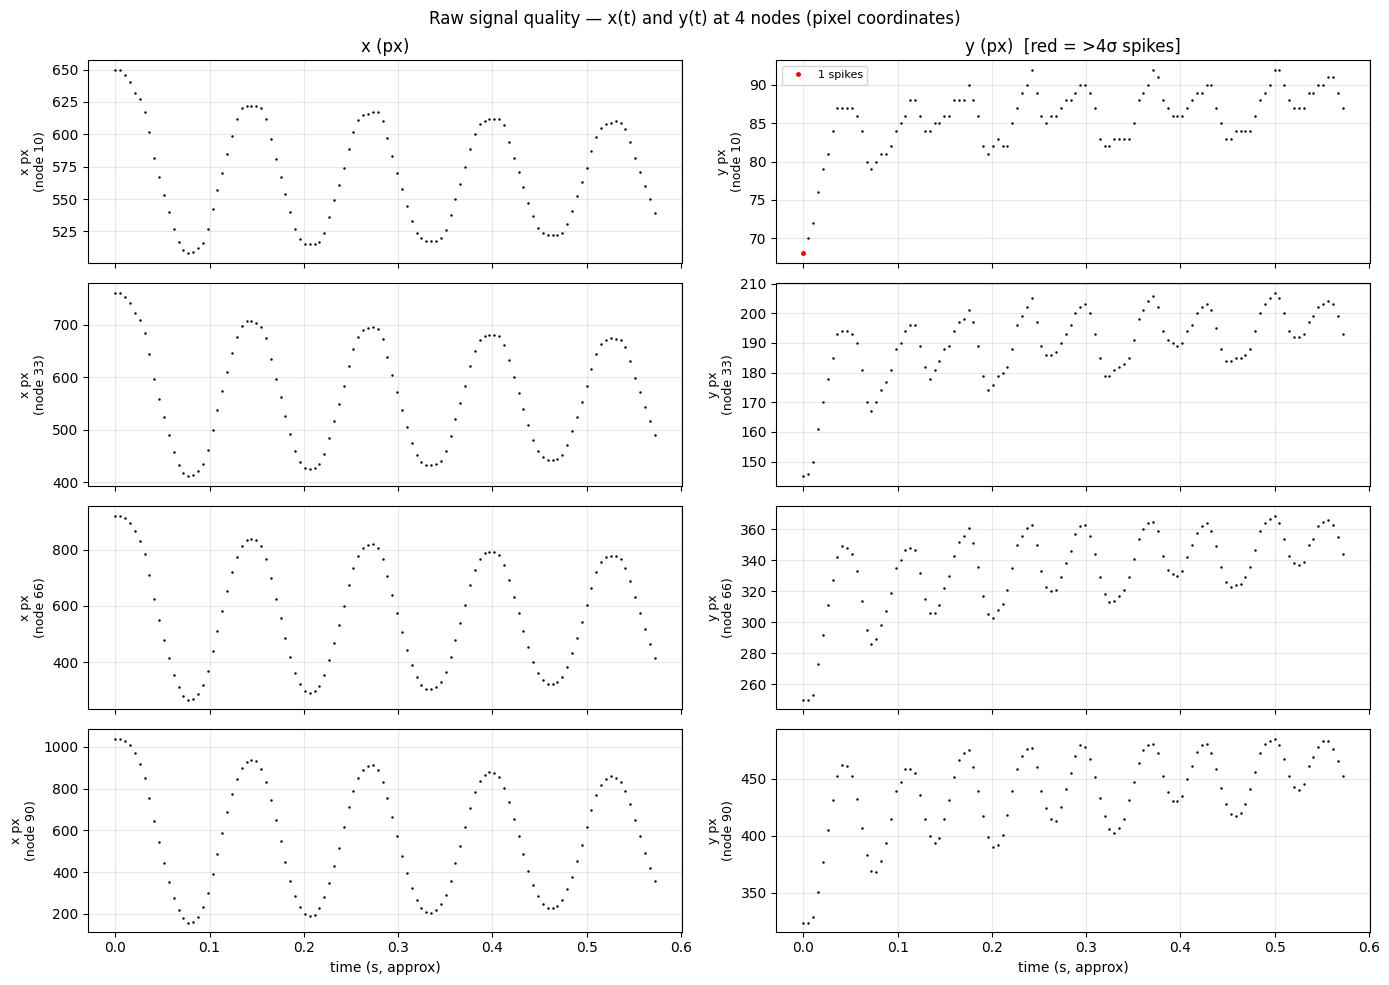


Copy the PIXELS_PER_METRE and CLAMP_PX lines above into cell-01-config, then re-run the notebook.


In [642]:
# ── Live data calibration ─────────────────────────────────────────────────
# Run this cell after recording a new session to get the values to paste
# into the config cell above (cell-01-config).
# Requires: INPUT_TXT, L0  (from cell-01-config)
# N_VIDEO_PTS is auto-detected from the file
# ──────────────────────────────────────────────────────────────────────────

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# _raw = sio.loadmat(INPUT_MAT)
_data_txt   = np.loadtxt(INPUT_TXT)
_n_frames   = _data_txt.shape[0]
N_VIDEO_PTS = (_data_txt.shape[1] - 1) // 2  # auto-detect: 100 (old) or 25 (ros_centerline_2)
_x_px  = _data_txt[:, :N_VIDEO_PTS].astype(float)
_y_px  = _data_txt[:, N_VIDEO_PTS:2*N_VIDEO_PTS].astype(float)
_z_idx = _data_txt[:, 2*N_VIDEO_PTS].astype(float)
# _x_flat = _raw['x'].ravel().astype(float)
# _y_flat = _raw['y'].ravel().astype(float)
# _z_flat = _raw['z'].ravel().astype(float)

# _n_total  = len(_x_flat)
# _n_frames = _n_total // N_VIDEO_PTS
# assert _n_total % N_VIDEO_PTS == 0, \
#     f'Total points {_n_total} not divisible by N_VIDEO_PTS={N_VIDEO_PTS}'

# _x_px = _x_flat.reshape(_n_frames, N_VIDEO_PTS)
# _y_px = _y_flat.reshape(_n_frames, N_VIDEO_PTS)
# _z_idx = _z_flat.reshape(_n_frames, N_VIDEO_PTS)[:, 0]

print(f'Loaded {_n_frames} frames × {N_VIDEO_PTS} pts from {INPUT_TXT}')
print(f'Frame index range: {int(_z_idx.min())} → {int(_z_idx.max())}')

# ── 1. PIXELS_PER_METRE ──────────────────────────────────────────────────
_ds  = np.sqrt(np.diff(_x_px, axis=1)**2 + np.diff(_y_px, axis=1)**2)
_arc = _ds.sum(axis=1)
_med_arc = float(np.median(_arc))
_ppm = _med_arc / L0

print(f'\n--- Calibration values (paste into cell-01-config) ---')
print(f'PIXELS_PER_METRE = {_ppm:.1f}   '
      f'(median arc = {_med_arc:.1f} px, L0 = {L0} m → {1/_ppm*1000:.3f} mm/px)')

# ── 2. CLAMP_PX — identify by minimum variance across frames ─────────────
_x_std = _x_px.std(axis=0)
_y_std = _y_px.std(axis=0)
_clamp_node = int(np.argmin(_x_std + _y_std))
_clamp_x = float(_x_px[0, _clamp_node])
_clamp_y = float(_y_px[0, _clamp_node])
print(f'CLAMP_PX = np.array([{_clamp_x:.1f}, {_clamp_y:.1f}])  '
      f'(node {_clamp_node}, std={(_x_std+_y_std)[_clamp_node]:.2f} px)')

# ── 3. Arc-length outlier frames (>20% from median) ──────────────────────
_arc_tol = 0.20
_arc_bad  = np.where(np.abs(_arc - _med_arc) / _med_arc > _arc_tol)[0]
print(f'\n--- Data quality ---')
print(f'Arc-length outliers (>{_arc_tol*100:.0f}% from median): '
      f'{len(_arc_bad)} / {_n_frames} frames'
      + (f'  → frames {_arc_bad[:10].tolist()}{"…" if len(_arc_bad)>10 else ""}' if len(_arc_bad) else ''))

# ── 4. Tip-jump outliers (node furthest from clamp = max variance) ────────
_tip_node = int(np.argmax(_x_std + _y_std))
_tip_x = _x_px[:, _tip_node]
_tip_y = _y_px[:, _tip_node]
_tip_jump = np.sqrt(np.diff(_tip_x)**2 + np.diff(_tip_y)**2)
_jump_thr = 15.0
_jump_bad = np.where(_tip_jump > _jump_thr)[0] + 1
print(f'Tip-jump outliers (>{_jump_thr:.0f} px/frame, node {_tip_node}): '
      f'{len(_jump_bad)} / {_n_frames} frames'
      + (f'  → frames {_jump_bad[:10].tolist()}{"…" if len(_jump_bad)>10 else ""}' if len(_jump_bad) else ''))

# ── 5. Summary plot — x(t) and y(t) at 4 nodes ──────────────────────────
_inspect = [int(N_VIDEO_PTS * f) for f in (0.1, 0.33, 0.66, 0.9)]  # auto-scale to N_VIDEO_PTS
_t = (_z_idx - _z_idx[0]) / FPS

fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True, dpi=100)
fig.suptitle('Raw signal quality — x(t) and y(t) at 4 nodes (pixel coordinates)', fontsize=12)
for _row, _col in enumerate(_inspect):
    _xc = _x_px[:, _col]
    _yc = _y_px[:, _col]
    _mu, _sd = _yc.mean(), _yc.std()
    _spk = np.abs(_yc - _mu) > 4 * _sd

    ax = axes[_row, 0]
    ax.plot(_t, _xc, 'k.', ms=1.5)
    ax.set_ylabel(f'x px\n(node {_col})', fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = axes[_row, 1]
    ax.plot(_t, _yc, 'k.', ms=1.5)
    if _spk.any():
        ax.plot(_t[_spk], _yc[_spk], 'r.', ms=5, label=f'{_spk.sum()} spikes')
        ax.legend(fontsize=8)
    ax.set_ylabel(f'y px\n(node {_col})', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0, 0].set_title('x (px)')
axes[0, 1].set_title('y (px)  [red = >4σ spikes]')
axes[-1, 0].set_xlabel('time (s, approx)')
axes[-1, 1].set_xlabel('time (s, approx)')
plt.tight_layout()
plt.show()

print('\nCopy the PIXELS_PER_METRE and CLAMP_PX lines above into cell-01-config, then re-run the notebook.')


## Step 2 — Load raw pixel data

The `.mat` file from `skeletonization.ipynb` contains three flat 1-D arrays:
- `x` — pixel column (horizontal), length = N_VIDEO_PTS × n_frames
- `y` — pixel row (vertical), length = N_VIDEO_PTS × n_frames
- `z` — frame index for each point

We reshape into `(n_frames, N_VIDEO_PTS)` arrays.

In [643]:
# ── Step 2: Load raw pixel data ──────────────────────────────────────────
# Each row in the .txt file: [x0..x(N-1), y0..y(N-1), frame_index]
# N_VIDEO_PTS is inferred from the column count: (n_cols - 1) // 2
# raw = sio.loadmat(INPUT_MAT)
# print('Keys in file:', [k for k in raw.keys() if not k.startswith('_')])
# x_flat = raw['x'].ravel().astype(float)
# y_flat = raw['y'].ravel().astype(float)
# z_flat = raw['z'].ravel().astype(float)   # frame indices
# n_total = len(x_flat)
# n_frames = n_total // N_VIDEO_PTS

data_txt    = np.loadtxt(INPUT_TXT)             # (n_frames, 2*N_VIDEO_PTS + 1)
N_VIDEO_PTS = (data_txt.shape[1] - 1) // 2  # auto-detect: 100 (old) or 25 (ros_centerline_2)
N_TRAIN_PTS = N_VIDEO_PTS                    # train GPs on all available points
n_frames    = data_txt.shape[0]
x_px     = data_txt[:, :N_VIDEO_PTS].astype(float)           # (n_frames, N_VIDEO_PTS)
y_px     = data_txt[:, N_VIDEO_PTS:2*N_VIDEO_PTS].astype(float)
frame_indices = data_txt[:, 2*N_VIDEO_PTS].astype(float)     # (n_frames,)

# Trim initial transient frames
if TRIM_FRAMES > 0:
    x_px          = x_px[TRIM_FRAMES:]
    y_px          = y_px[TRIM_FRAMES:]
    frame_indices = frame_indices[TRIM_FRAMES:]
    n_frames      = len(frame_indices)
    print(f'Trimmed {TRIM_FRAMES} frames from start → {n_frames} frames remaining')

print(f'Loaded {n_frames} frames × {N_VIDEO_PTS} points  (N_TRAIN_PTS={N_TRAIN_PTS})')
print(f'Frame index range: {int(frame_indices.min())} → {int(frame_indices.max())}')
print(f'x range: [{x_px.min():.0f}, {x_px.max():.0f}] px')
print(f'y range: [{y_px.min():.0f}, {y_px.max():.0f}] px')


Loaded 112 frames × 100 points  (N_TRAIN_PTS=100)
Frame index range: 0 → 111
x range: [119, 1084] px
y range: [1, 527] px


## Step 3 — Pixel-to-metre calibration & coordinate orientation

**Scale:** If `PIXELS_PER_METRE = None`, the scale is auto-derived from the
median pixel arc-length across all frames (assuming the rod is inextensible at L0).
The printed value tells you what to hard-code if you want to fix it.

**Origin:** Clamp pixel is shifted to (0, 0).

**y-axis:** Pixel rows increase downward; we flip so y increases upward.

**Orientation (optional):** The real rod is vertically clamped (hangs down).
If `ROTATE_TO_HORIZONTAL = True`, we apply a 90° clockwise rotation so the rod
extends rightward — matching the simulation's initial condition.

Auto-calibration:
  Median pixel arc length = 560.4 px
  → PIXELS_PER_METRE = 1474.8  (hard-code this in config to fix it)

Clamp point max deviation: x=0.0 mm, y=0.0 mm
Arc length: mean=0.379 m  std=0.020 m  (expected ~0.38 m)

Tip position range (node -1):
  x_tip: [-0.306, 0.349] m
  y_tip: [-0.357, -0.237] m


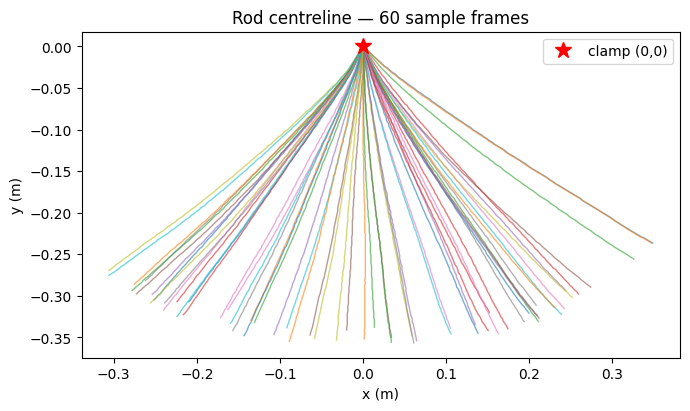


Arc length should be ≈ L0.  If not, check PIXELS_PER_METRE and CLAMP_PX.


In [644]:
# ── Step 3a: Auto-calibrate scale if needed ────────────────────────────────
if PIXELS_PER_METRE is None:
    ds_px = np.sqrt(np.diff(x_px, axis=1)**2 + np.diff(y_px, axis=1)**2)
    arc_px = ds_px.sum(axis=1)
    median_arc_px = np.median(arc_px)
    scale = median_arc_px / L0
    print(f'Auto-calibration:')
    print(f'  Median pixel arc length = {median_arc_px:.1f} px')
    print(f'  → PIXELS_PER_METRE = {scale:.1f}  (hard-code this in config to fix it)')
else:
    scale = PIXELS_PER_METRE
    print(f'Using fixed PIXELS_PER_METRE = {scale}')

# ── Step 3b: Convert to metres, origin at clamp (node 0) ──────────────────
# Node 0 is the clamp (confirmed by zero variance across all frames).
# Pixel convention: x = column (rightward), y = row (downward).
# Physical convention: x rightward, y upward  →  flip y.
x_m = ( x_px - CLAMP_PX[0]) / scale
y_m = -(y_px - CLAMP_PX[1]) / scale

# ── Step 3c: Optional 90° clockwise rotation ───────────────────────────────
if ROTATE_TO_HORIZONTAL:
    x_m_rot = -y_m.copy()
    y_m_rot =  x_m.copy()
    x_m, y_m = x_m_rot, y_m_rot
    print('90° rotation applied: rod now extends rightward from clamp.')

# ── Time vector ─────────────────────────────────────────────────────────────
t_raw = (frame_indices - frame_indices[0]) / FPS

# ── Diagnostics ─────────────────────────────────────────────────────────────
clamp_x_err = np.abs(x_m[:, 0]).max()
clamp_y_err = np.abs(y_m[:, 0]).max()
print(f'\nClamp point max deviation: x={clamp_x_err*1000:.1f} mm, y={clamp_y_err*1000:.1f} mm')

ds_approx = np.sqrt(np.diff(x_m, axis=1)**2 + np.diff(y_m, axis=1)**2)
arc_len = ds_approx.sum(axis=1)
print(f'Arc length: mean={arc_len.mean():.3f} m  std={arc_len.std():.3f} m  (expected ~{L0} m)')
print(f'\nTip position range (node -1):')
print(f'  x_tip: [{x_m[:,-1].min():.3f}, {x_m[:,-1].max():.3f}] m')
print(f'  y_tip: [{y_m[:,-1].min():.3f}, {y_m[:,-1].max():.3f}] m')

# ── Visualise ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
for i in np.linspace(0, n_frames-1, 60, dtype=int):
    ax.plot(x_m[i], y_m[i], alpha=0.6, lw=1)
ax.plot(0, 0, 'r*', ms=12, label='clamp (0,0)')
ax.set_aspect('equal')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
title = 'Rod centreline — 60 sample frames'
if ROTATE_TO_HORIZONTAL:
    title += ' [rotated to horizontal]'
ax.set_title(title)
ax.legend()
plt.tight_layout()
plt.show()

print('\nArc length should be ≈ L0.  If not, check PIXELS_PER_METRE and CLAMP_PX.')


## Step 3b — Raw data inspection before GP training

Plot x(t) and y(t) at four nodes along the rod to understand the signal before any smoothing.

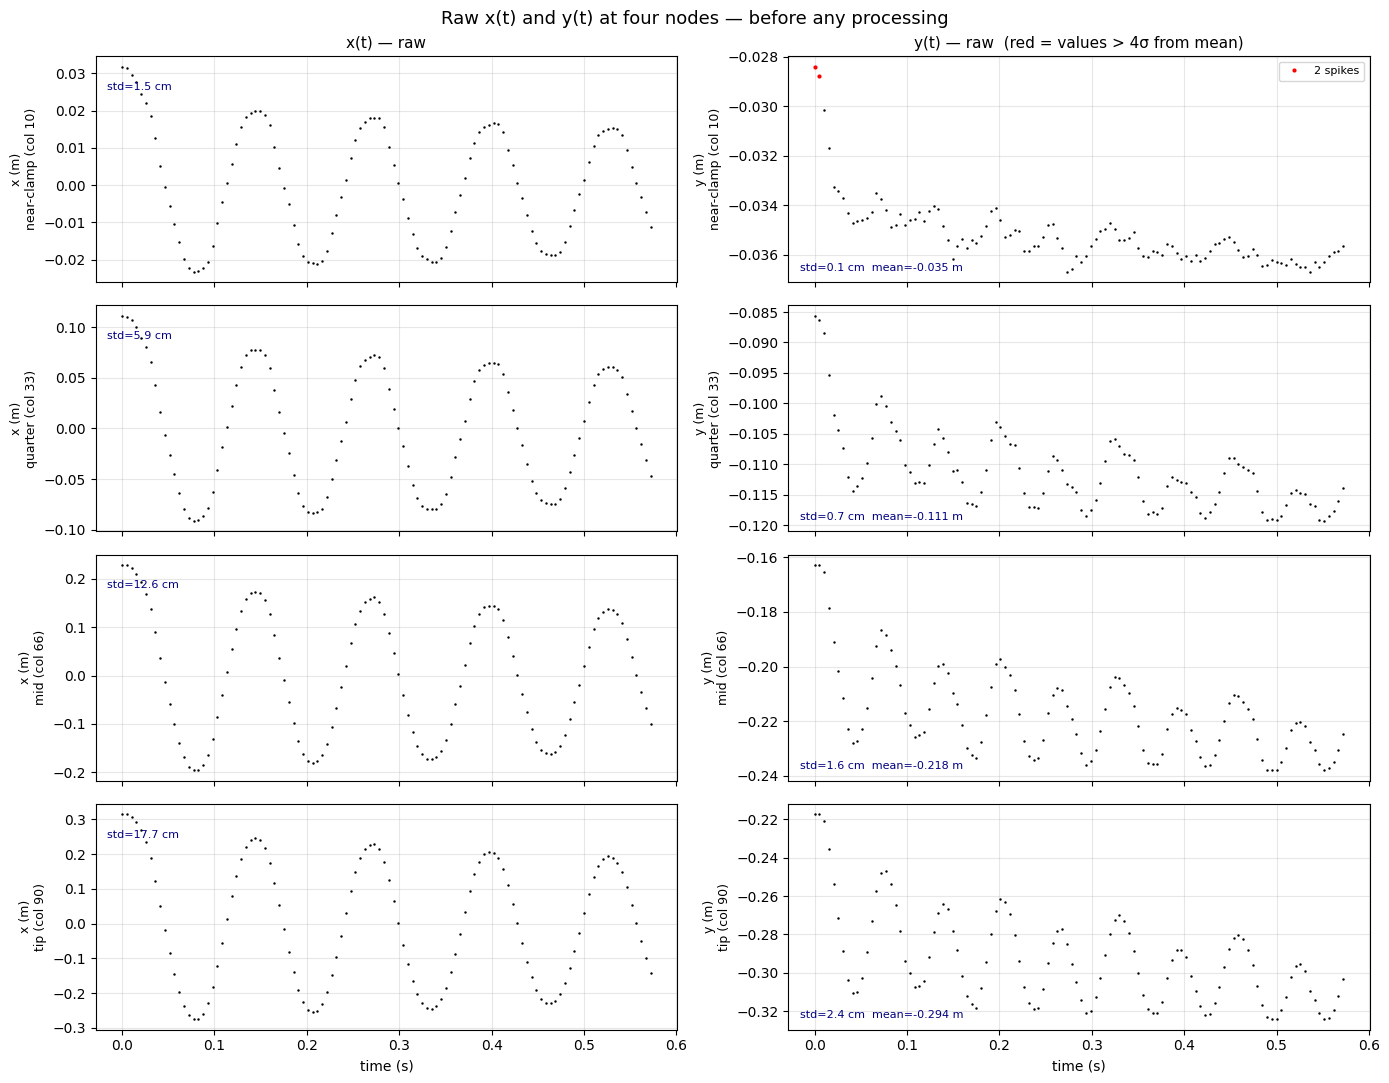

  node    x mean    x std   x range |    y mean    y std   y range  y spikes
---------------------------------------------------------------------------
    10    0.0001   0.0151    0.0551 |   -0.0352   0.0013    0.0083         2
    33   -0.0009   0.0587    0.2028 |   -0.1113   0.0065    0.0338         0
    66   -0.0004   0.1261    0.4246 |   -0.2176   0.0159    0.0752         0
    90   -0.0015   0.1769    0.5912 |   -0.2936   0.0238    0.1072         0


In [645]:
from scipy.interpolate import interp1d as _interp1d

# Resample to equidistant nodes (same as Step 4a — just for inspection)
def _resample(x_row, y_row, n_out):
    ds = np.sqrt(np.diff(x_row)**2 + np.diff(y_row)**2)
    s  = np.concatenate([[0.0], np.cumsum(ds)])
    xi = _interp1d(s, x_row)(np.linspace(0, s[-1], n_out))
    yi = _interp1d(s, y_row)(np.linspace(0, s[-1], n_out))
    return xi, yi

x_raw_all = np.zeros((n_frames, N_VIDEO_PTS))
y_raw_all = np.zeros((n_frames, N_VIDEO_PTS))
for i in range(n_frames):
    x_raw_all[i], y_raw_all[i] = _resample(x_m[i], y_m[i], N_VIDEO_PTS)

# Four representative nodes: near-clamp, quarter, mid, tip
# Use x_raw_all column count as ground truth to avoid stale N_VIDEO_PTS from config cell
_n_pts_actual = x_raw_all.shape[1]
inspect_cols = [int(_n_pts_actual * f) for f in (0.1, 0.33, 0.66, 0.9)]
inspect_cols = [min(c, _n_pts_actual - 1) for c in inspect_cols]  # safety clamp
labels       = [f'near-clamp (col {inspect_cols[0]})', f'quarter (col {inspect_cols[1]})',
                f'mid (col {inspect_cols[2]})', f'tip (col {inspect_cols[3]})']

fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharex=True, dpi=100)
fig.suptitle('Raw x(t) and y(t) at four nodes — before any processing', fontsize=13)

for row, (col, lbl) in enumerate(zip(inspect_cols, labels)):
    xc = x_raw_all[:, col]
    yc = y_raw_all[:, col]
# !pip install --upgrade nbformat
    # Mark y spikes: values more than 4 std from mean
    mu_y, sd_y = yc.mean(), yc.std()
    spike_mask = np.abs(yc - mu_y) > 4 * sd_y

    ax = axes[row, 0]
    ax.plot(t_raw, xc, 'k.', ms=1.5)
    ax.set_ylabel(f'x (m)\n{lbl}', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.annotate(f'std={xc.std()*100:.1f} cm', xy=(0.02, 0.85),
                xycoords='axes fraction', fontsize=8, color='navy')

    ax = axes[row, 1]
    ax.plot(t_raw, yc, 'k.', ms=1.5)
    if spike_mask.any():
        ax.plot(t_raw[spike_mask], yc[spike_mask], 'r.', ms=4,
                label=f'{spike_mask.sum()} spikes')
        ax.legend(fontsize=8, loc='upper right')
    ax.set_ylabel(f'y (m)\n{lbl}', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.annotate(f'std={yc.std()*100:.1f} cm  mean={yc.mean():.3f} m',
                xy=(0.02, 0.05), xycoords='axes fraction', fontsize=8, color='navy')

axes[0, 0].set_title('x(t) — raw', fontsize=11)
axes[0, 1].set_title('y(t) — raw  (red = values > 4σ from mean)', fontsize=11)
axes[-1, 0].set_xlabel('time (s)')
axes[-1, 1].set_xlabel('time (s)')
plt.tight_layout()
plt.show()

# Simple summary table
print(f'{"node":>6} {"x mean":>9} {"x std":>8} {"x range":>9} | {"y mean":>9} {"y std":>8} {"y range":>9} {"y spikes":>9}')
print('-' * 75)
for col, lbl in zip(inspect_cols, labels):
    xc = x_raw_all[:, col]; yc = y_raw_all[:, col]
    mu_y, sd_y = yc.mean(), yc.std()
    n_spikes = (np.abs(yc - mu_y) > 4 * sd_y).sum()
    print(f'{col:>6} {xc.mean():>9.4f} {xc.std():>8.4f} {xc.max()-xc.min():>9.4f} | '
          f'{yc.mean():>9.4f} {yc.std():>8.4f} {yc.max()-yc.min():>9.4f} {n_spikes:>9}')


## Step 3c — 3D surface: raw x(t, node)

Raw horizontal position before GP smoothing.

In [646]:
# !pip install --upgrade nbformat

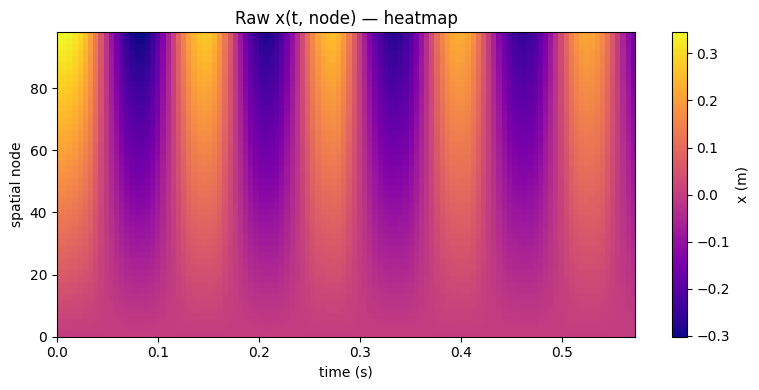

In [647]:
import plotly.graph_objects as go
from scipy.interpolate import interp1d as _i1d

# Arc-length resample raw data to uniform 100-pt grid
_xr = np.zeros((n_frames, N_VIDEO_PTS))
_yr = np.zeros((n_frames, N_VIDEO_PTS))
for _i in range(n_frames):
    _ds = np.sqrt(np.diff(x_m[_i])**2 + np.diff(y_m[_i])**2)
    _s  = np.concatenate([[0.0], np.cumsum(_ds)])
    _su = np.linspace(0, _s[-1], N_VIDEO_PTS)
    _xr[_i] = _i1d(_s, x_m[_i])(_su)
    _yr[_i] = _i1d(_s, y_m[_i])(_su)

t_plot    = t_raw[::1]
node_plot = np.arange(0, N_VIDEO_PTS, 2)
X_surf_raw = _xr[::1, :][:, node_plot]

# ── Plotly 3D surface (rotatable) ─────────────────────────────────────────
fig3d = go.Figure(go.Surface(
    x=t_plot, y=node_plot, z=X_surf_raw.T,
    colorscale='plasma', colorbar=dict(title='x (m)'),
    contours=dict(z=dict(show=False))
))
fig3d.update_layout(
    title='Raw x(t, node) — 3D surface',
    scene=dict(
        xaxis_title='time (s)',
        yaxis_title='spatial node',
        zaxis_title='x (m)',
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.8))
    ),
    width=700, height=500, margin=dict(l=0, r=0, t=40, b=0)
)
fig3d.show()

# ── Matplotlib heatmap (inline, resizable) ────────────────────────────────
fig2d, ax = plt.subplots(figsize=(8, 4), dpi=100)
im = ax.imshow(X_surf_raw.T, aspect='auto', origin='lower',
               extent=[t_plot[0], t_plot[-1], node_plot[0], node_plot[-1]],
               cmap='plasma')
fig2d.colorbar(im, ax=ax, label='x (m)')
ax.set_xlabel('time (s)')
ax.set_ylabel('spatial node')
ax.set_title('Raw x(t, node) — heatmap')
plt.tight_layout()
plt.show()

## Step 3d — 3D surface: raw y(t, node)

Raw vertical position before GP smoothing.

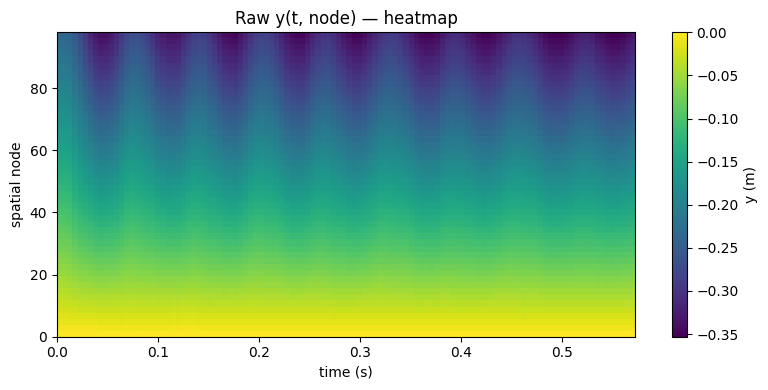

In [648]:
import plotly.graph_objects as go

# _yr, t_plot, node_plot are defined in the surf-raw-x cell above.
# Re-define node_plot/t_plot here in case this cell is run independently.
t_plot    = t_raw[::1   ]
node_plot = np.arange(0, N_VIDEO_PTS, 2)
Y_surf_raw = _yr[::1, :][:, node_plot]

# ── Plotly 3D surface (rotatable) ─────────────────────────────────────────
fig3d = go.Figure(go.Surface(
    x=t_plot, y=node_plot, z=Y_surf_raw.T,
    colorscale='viridis', colorbar=dict(title='y (m)'),
))
fig3d.update_layout(
    title='Raw y(t, node) — 3D surface',
    scene=dict(
        xaxis_title='time (s)',
        yaxis_title='spatial node',
        zaxis_title='y (m)',
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.8))
    ),
    width=700, height=500, margin=dict(l=0, r=0, t=40, b=0)
)
fig3d.show()

# ── Matplotlib heatmap (inline, resizable) ────────────────────────────────
fig2d, ax = plt.subplots(figsize=(8, 4), dpi=100)
im = ax.imshow(Y_surf_raw.T, aspect='auto', origin='lower',
               extent=[t_plot[0], t_plot[-1], node_plot[0], node_plot[-1]],
               cmap='viridis')
fig2d.colorbar(im, ax=ax, label='y (m)')
ax.set_xlabel('time (s)')
ax.set_ylabel('spatial node')
ax.set_title('Raw y(t, node) — heatmap')
plt.tight_layout()
plt.show()

# Surface plot (Raw data)

In [649]:
# !pip install plotly
# !pip install nbformat

In [650]:
import numpy as np
import plotly.graph_objects as go

# Subsample frames for speed (every 4th frame)
_stride = 1
_frames = np.arange(0, n_frames, _stride)
_n_pts  = N_VIDEO_PTS

# Grids: rows = spatial nodes, cols = subsampled frames
X_grid = x_m[_frames, :].T                        # (n_pts, n_t)  horizontal position
T_grid = np.tile(t_raw[_frames], (_n_pts, 1))      # (n_pts, n_t)  time
Y_grid = y_m[_frames, :].T                        # (n_pts, n_t)  vertical position

# ── Plotly 3D surface (rotatable) ─────────────────────────────────────────
fig3d = go.Figure(go.Surface(
    x=T_grid,
    y=X_grid,
    z=Y_grid,
    colorscale='viridis',
    colorbar=dict(title='y (m)'),
))
fig3d.update_layout(
    title='Rod deformation surface (Raw data)',
    scene=dict(
        xaxis_title='time (s)',
        yaxis_title='horizontal x (m)',
        zaxis_title='vertical y (m)',
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.8))
    ),
    width=750, height=550, margin=dict(l=0, r=0, t=40, b=0)
)
fig3d.show()

# ── Static Matplotlib version (saved to file) ─────────────────────────────
# fig2, ax2 = plt.subplots(figsize=(8, 5), dpi=100,
#                           subplot_kw=dict(projection='3d'))
# ax2.plot_surface(X_grid, T_grid, Y_grid,
#                  cmap='viridis', linewidth=0, antialiased=True, alpha=0.85)
# ax2.set_xlabel('Horizontal x (m)')
# ax2.set_ylabel('Time (s)')
# ax2.set_zlabel('Vertical y (m)')
# ax2.set_title('Rod deformation surface')
# plt.tight_layout()
# plt.savefig('../Figure_1.png', dpi=150, bbox_inches='tight')
# plt.show()

# GP training 

In [651]:
# !pip install scikit-learn

In [652]:
# ──────────────────────────────────────────────────────────────────────────────
# Step 4: Gaussian Process regression to smooth and interpolate in time
import warnings
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning
from scipy.interpolate import interp1d

# ── Helper: arc-length resample a single frame ──────────────────────────────
def resample_arc(x_row, y_row, n_out):
    ds = np.sqrt(np.diff(x_row)**2 + np.diff(y_row)**2)
    s  = np.concatenate([[0.0], np.cumsum(ds)])
    s_uniform = np.linspace(0, s[-1], n_out)
    xi = interp1d(s, x_row, kind='linear')(s_uniform)
    yi = interp1d(s, y_row, kind='linear')(s_uniform)
    return xi, yi

# ── Step 4a: Resample raw 100 pts → N_TRAIN_PTS equidistant points per frame ─
print(f'Step 4a: resampling {N_VIDEO_PTS} raw pts → {N_TRAIN_PTS} spatial nodes ...')
x_train_all = np.zeros((n_frames, N_TRAIN_PTS))
y_train_all = np.zeros((n_frames, N_TRAIN_PTS))
for i in range(n_frames):
    x_train_all[i], y_train_all[i] = resample_arc(x_m[i], y_m[i], N_TRAIN_PTS)
x_train_all[:, 0] = 0.0
y_train_all[:, 0] = 0.0
print(f'  Done.  Shape: {x_train_all.shape}')

# ── Step 4b: Identify and remove outlier frames ────────────────────────────
bad_mask = np.zeros(n_frames, dtype=bool)
for _k in range(N_TRAIN_PTS):
    _yc = y_train_all[:, _k]
    _sd = _yc.std()
    if _sd > 1e-9:
        bad_mask |= (np.abs(_yc - _yc.mean()) > 4 * _sd)
good_mask = ~bad_mask

print(f'Step 4b: outlier frame detection ...')
print(f'  Bad frames (any y col > 4σ): {bad_mask.sum()} / {n_frames}')
print(f'  Bad frame times (s): {t_raw[bad_mask].round(3)}')
print(f'  Good frames for GP training: {good_mask.sum()}')

t_col = t_raw.reshape(-1, 1)
t_sub = t_raw[good_mask][::GP_STRIDE].reshape(-1, 1)
print(f'  Training subset (stride={GP_STRIDE}): {len(t_sub)} frames')

# ── Step 4c: Train one GP per spatial column ───────────────────────────────
# LS_X        = 0.66
# LS_Y_NEAR   = 0.66
# LS_Y_FAR    = 0.33
# Y_LS_SWITCH = 45
LS_X        = 0.10
LS_Y_NEAR   = 0.10
LS_Y_FAR    = 0.05
Y_LS_SWITCH = 45


print(f'Step 4c: training {N_TRAIN_PTS-1} GPs on {len(t_sub)} frames (stride={GP_STRIDE}) ...')
print(f'  LS_X={LS_X}s  LS_Y_NEAR={LS_Y_NEAR}s  LS_Y_FAR={LS_Y_FAR}s')

x_gp_all = np.zeros((n_frames, N_TRAIN_PTS))
y_gp_all = np.zeros((n_frames, N_TRAIN_PTS))

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always', ConvergenceWarning)

    for k in range(1, N_TRAIN_PTS):
        if k % 10 == 0:
            print(f'  node {k}/{N_TRAIN_PTS} ...', end='\r')

        ls_y = LS_Y_NEAR if k < Y_LS_SWITCH else LS_Y_FAR

        y_tr   = x_train_all[good_mask, k][::GP_STRIDE]
        kernel = (Matern(length_scale=LS_X,
                         length_scale_bounds=(LS_X/3, LS_X*3), nu=2.5)
                  + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-2)))
        gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-4,
                                       normalize_y=True, n_restarts_optimizer=3)
        gpr.fit(t_sub, y_tr)
        x_gp_all[:, k] = gpr.predict(t_col)

        y_tr   = y_train_all[good_mask, k][::GP_STRIDE]
        kernel = (Matern(length_scale=ls_y,
                         length_scale_bounds=(ls_y/3, ls_y*3), nu=2.5)
                  + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-2)))
        gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-4,
                                       normalize_y=True, n_restarts_optimizer=3)
        gpr.fit(t_sub, y_tr)
        y_gp_all[:, k] = gpr.predict(t_col)

warn_count = sum(1 for w in caught if issubclass(w.category, ConvergenceWarning))
print(f'\n  Done. ConvergenceWarnings: {warn_count}  (0 = clean; a few is OK)')
print(f'  x_gp_all, y_gp_all: {x_gp_all.shape}')


Step 4a: resampling 100 raw pts → 100 spatial nodes ...
  Done.  Shape: (112, 100)
Step 4b: outlier frame detection ...
  Bad frames (any y col > 4σ): 2 / 112
  Bad frame times (s): [0.    0.005]
  Good frames for GP training: 110
  Training subset (stride=2): 55 frames
Step 4c: training 99 GPs on 55 frames (stride=2) ...
  LS_X=0.1s  LS_Y_NEAR=0.1s  LS_Y_FAR=0.05s
  node 90/100 ...
  Done. ConvergenceWarnings: 161  (0 = clean; a few is OK)
  x_gp_all, y_gp_all: (112, 100)


In [657]:
# ── Step 4d: Subsample N_TRAIN_PTS → N+1 nodes (for x, y) ────────────────
# Run this cell independently after GP training — no need to re-train.
# Requires: x_gp_all, y_gp_all, resample_arc  (from cell above)
n_nodes = N + 1
print(f'Step 4d: subsampling GP predictions → {n_nodes} nodes for x, y ...')
# Resample GP predictions onto exactly N+1 nodes spaced uniformly over L0.
# We walk along the predicted arc but stop at s=L0, so segment lengths = ds=L0/N.
def resample_arc_L0(x_row, y_row, n_out, arc_len):
    ds_seg = np.sqrt(np.diff(x_row)**2 + np.diff(y_row)**2)
    s = np.concatenate([[0.0], np.cumsum(ds_seg)])
    s_clip = min(s[-1], arc_len)          # never exceed the GP arc
    s_uniform = np.linspace(0, s_clip, n_out)
    xi = interp1d(s, x_row, kind='linear')(s_uniform)
    yi = interp1d(s, y_row, kind='linear')(s_uniform)
    return xi, yi

x_smooth = np.zeros((n_frames, n_nodes))
y_smooth = np.zeros((n_frames, n_nodes))
for i in range(n_frames):
    x_smooth[i], y_smooth[i] = resample_arc_L0(x_gp_all[i], y_gp_all[i], n_nodes, L0)
x_smooth[:, 0] = 0.0
y_smooth[:, 0] = 0.0
print(f'  x_smooth, y_smooth: {x_smooth.shape}')

# Verify segment lengths are now ≈ ds
_seg = np.sqrt(np.diff(x_smooth, axis=1)**2 + np.diff(y_smooth, axis=1)**2)
print(f'  Segment lengths: mean={_seg.mean():.4f}  std={_seg.std():.4f}  '
      f'min={_seg.min():.4f}  max={_seg.max():.4f}  (ds={L0/N:.4f})')

# ── Step 4e: Compute θ on a denser 50-node grid, then subsample to N ──────
# 50 nodes → 49 segments gives a smoother tangent angle than 26 nodes → 25.
N_THETA = 50
print(f'Step 4e: computing θ on {N_THETA}-node grid ({N_THETA-1} segments) ...')
x_dense = np.zeros((n_frames, N_THETA))
y_dense = np.zeros((n_frames, N_THETA))
for i in range(n_frames):
    x_dense[i], y_dense[i] = resample_arc(x_gp_all[i], y_gp_all[i], N_THETA)

dx_dense    = np.diff(x_dense, axis=1)              # (n_frames, N_THETA-1)
dy_dense    = np.diff(y_dense, axis=1)
theta_dense = np.arctan2(dy_dense, dx_dense)         # (n_frames, N_THETA-1)
for i in range(n_frames):
    theta_dense[i] = np.unwrap(theta_dense[i])

# Subsample N_THETA-1 = 49 segments → N = 25 segments evenly
seg_idx      = np.round(np.linspace(0, N_THETA - 2, N)).astype(int)
theta_smooth = theta_dense[:, seg_idx]               # (n_frames, N)

# ── Enforce clamped boundary: first segment angle is fixed ────────────────
theta_smooth[:, 0] = theta_smooth[:, 0].mean()

print(f'  theta_dense:  {theta_dense.shape}  ({N_THETA-1} segments, before subsampling)')
print(f'  theta_smooth: {theta_smooth.shape}  ({N} segments, after subsampling)')
print(f'  θ range: [{theta_smooth.min():.3f}, {theta_smooth.max():.3f}] rad'
      f'  ({np.degrees(theta_smooth.min()):.1f}°, {np.degrees(theta_smooth.max()):.1f}°)')

# ── Step 4f: Time derivatives by central finite difference ────────────────
print(f'Step 4f: computing ẋ, ẏ, θ̇ by finite difference ...')
dt       = 1.0 / FPS
xdot     = np.gradient(x_smooth,     dt, axis=0)    # (n_frames, N+1)
ydot     = np.gradient(y_smooth,     dt, axis=0)    # (n_frames, N+1)
thetadot = np.gradient(theta_smooth, dt, axis=0)    # (n_frames, N)

# Enforce zero velocity at the clamped node
xdot[:, 0] = 0.0
ydot[:, 0] = 0.0

print(f'  xdot range:     [{xdot.min():.3f}, {xdot.max():.3f}] m/s')
print(f'  ydot range:     [{ydot.min():.3f}, {ydot.max():.3f}] m/s')
print(f'  thetadot range: [{thetadot.min():.3f}, {thetadot.max():.3f}] rad/s')
print('Step 4 complete.')


Step 4d: subsampling GP predictions → 26 nodes for x, y ...
  x_smooth, y_smooth: (112, 26)
  Segment lengths: mean=0.0148  std=0.0005  min=0.0135  max=0.0152  (ds=0.0152)
Step 4e: computing θ on 50-node grid (49 segments) ...
  theta_dense:  (112, 49)  (49 segments, before subsampling)
  theta_smooth: (112, 25)  (25 segments, after subsampling)
  θ range: [-2.590, -0.466] rad  (-148.4°, -26.7°)
Step 4f: computing ẋ, ẏ, θ̇ by finite difference ...
  xdot range:     [-15.154, 14.430] m/s
  ydot range:     [-5.781, 3.968] m/s
  thetadot range: [-54.291, 58.454] rad/s
Step 4 complete.


# Segments angel plotting

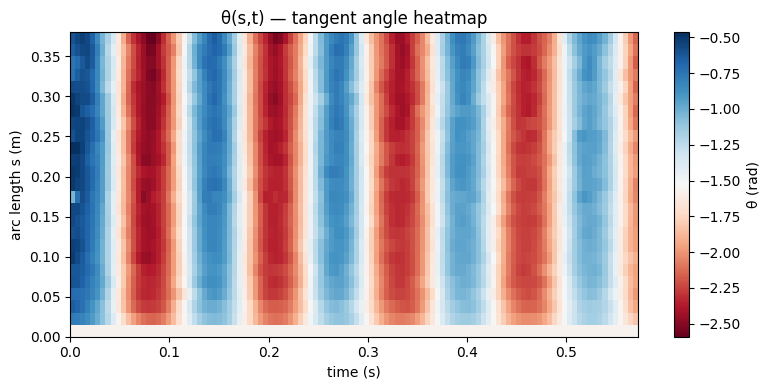

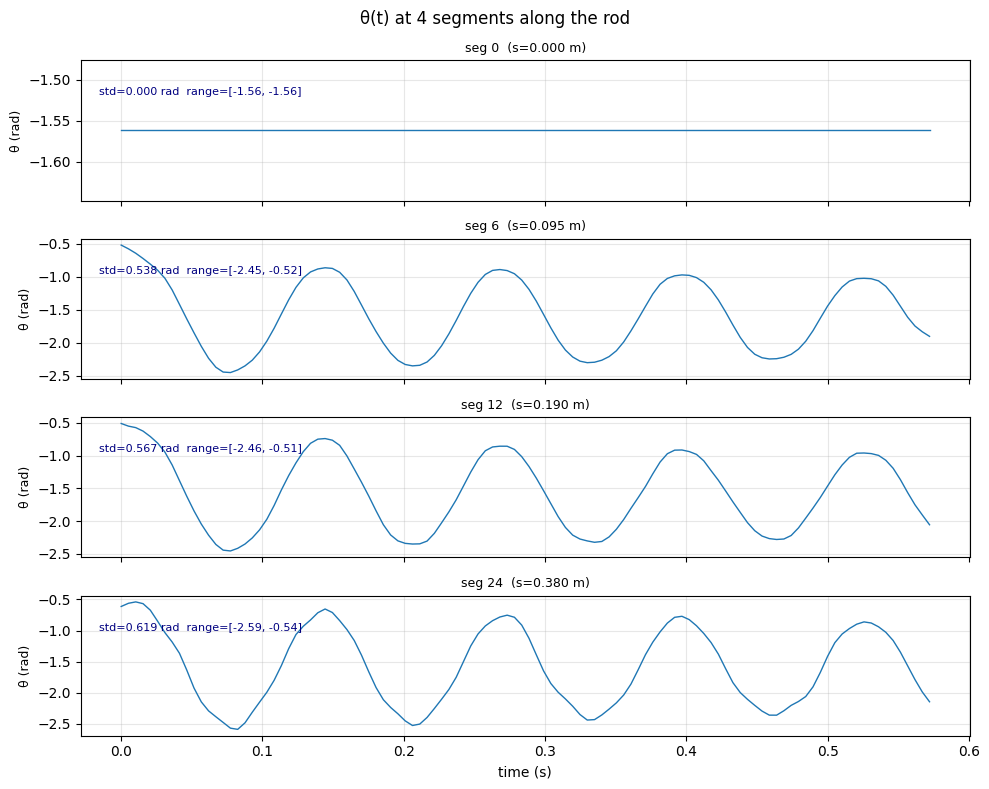

θ shape: (112, 25)  (25 segments × 112 frames)
θ range: [-2.590, -0.466] rad  (-148.4°, -26.7°)


In [659]:
import plotly.graph_objects as go

# ── θ(s,t) surface ────────────────────────────────────────────────────────
_stride    = 1
_fr        = np.arange(0, n_frames, _stride)
_s_theta   = np.linspace(0, L0, N)          # arc length at segment midpoints (m)
_THETA     = theta_smooth[_fr, :].T         # (N, n_t)
_t_ax      = t_raw[_fr]

fig = go.Figure(go.Surface(
    x=_t_ax, y=_s_theta, z=_THETA,
    colorscale='RdBu', cmid=0,
    colorbar=dict(title='θ (rad)')
))
fig.update_layout(
    title='θ(s,t) — tangent angle surface',
    scene=dict(
        xaxis_title='time (s)',
        yaxis_title='arc length s (m)',
        zaxis_title='θ (rad)',
        camera=dict(eye=dict(x=1.8, y=-1.8, z=0.9))
    ),
    width=750, height=500, margin=dict(l=0, r=0, t=40, b=0)
)
fig.show()

# ── θ heatmap ─────────────────────────────────────────────────────────────
fig2d, ax = plt.subplots(figsize=(8, 4), dpi=100)
im = ax.imshow(_THETA, aspect='auto', origin='lower',
               extent=[_t_ax[0], _t_ax[-1], 0, L0],
               cmap='RdBu')
fig2d.colorbar(im, ax=ax, label='θ (rad)')
ax.set_xlabel('time (s)')
ax.set_ylabel('arc length s (m)')
ax.set_title('θ(s,t) — tangent angle heatmap')
plt.tight_layout()
plt.show()

# ── θ(t) time series at 4 segments ────────────────────────────────────────
_seg_inspect = [0, N//4, N//2, N-1]
_seg_labels  = [f'seg {k}  (s={_s_theta[k]:.3f} m)' for k in _seg_inspect]

fig3, axes = plt.subplots(len(_seg_inspect), 1, figsize=(10, 8), sharex=True, dpi=100)
fig3.suptitle('θ(t) at 4 segments along the rod', fontsize=12)
for ax, k, lbl in zip(axes, _seg_inspect, _seg_labels):
    ax.plot(t_raw, theta_smooth[:, k], lw=1)
    ax.set_ylabel('θ (rad)', fontsize=9)
    ax.set_title(lbl, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.annotate(f'std={theta_smooth[:,k].std():.3f} rad  '
                f'range=[{theta_smooth[:,k].min():.2f}, {theta_smooth[:,k].max():.2f}]',
                xy=(0.02, 0.75), xycoords='axes fraction', fontsize=8, color='navy')
axes[-1].set_xlabel('time (s)')
plt.tight_layout()
plt.show()

print(f'θ shape: {theta_smooth.shape}  ({N} segments × {n_frames} frames)')
print(f'θ range: [{theta_smooth.min():.3f}, {theta_smooth.max():.3f}] rad  '
      f'({np.degrees(theta_smooth.min()):.1f}°, {np.degrees(theta_smooth.max()):.1f}°)')

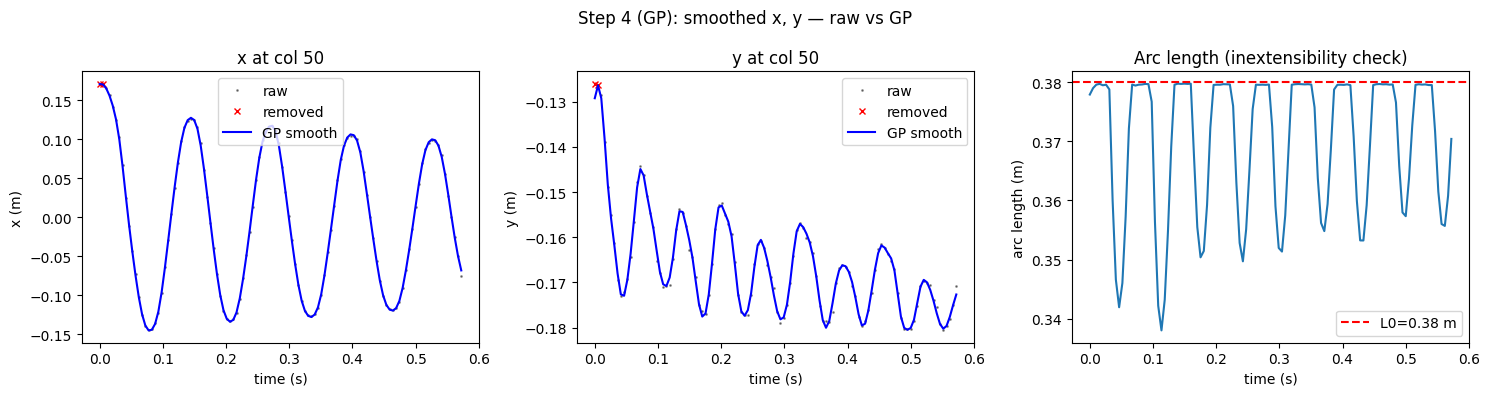


Step 4 complete.
  x_smooth: (112, 26)  y_smooth: (112, 26)
  xdot/ydot/theta/thetadot: zeros (skipped)


In [660]:
# ── Diagnostics ────────────────────────────────────────────────────────────
# Compare at the same spatial column (raw GP output vs raw data, same arc position)
# raw_col = midpoint column index (auto-scales to N_TRAIN_PTS)
raw_col = N_TRAIN_PTS // 2   # midpoint of the rod (auto-scales to N_TRAIN_PTS)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=100)

ax = axes[0]
ax.plot(t_raw, x_train_all[:, raw_col], 'k.', ms=2, alpha=0.4, label='raw')
ax.plot(t_raw[bad_mask], x_train_all[bad_mask, raw_col], 'rx', ms=5, label='removed')
ax.plot(t_raw, x_gp_all[:, raw_col], 'b-', lw=1.5, label='GP smooth')
ax.set_xlabel('time (s)'); ax.set_ylabel('x (m)')
ax.set_title(f'x at col {raw_col}'); ax.legend()

ax = axes[1]
ax.plot(t_raw, y_train_all[:, raw_col], 'k.', ms=2, alpha=0.4, label='raw')
ax.plot(t_raw[bad_mask], y_train_all[bad_mask, raw_col], 'rx', ms=5, label='removed')
ax.plot(t_raw, y_gp_all[:, raw_col], 'b-', lw=1.5, label='GP smooth')
ax.set_xlabel('time (s)'); ax.set_ylabel('y (m)')
ax.set_title(f'y at col {raw_col}'); ax.legend()

ax = axes[2]
arc = np.sqrt(np.diff(x_smooth, axis=1)**2 + np.diff(y_smooth, axis=1)**2).sum(axis=1)
ax.plot(t_raw, arc)
ax.axhline(L0, color='r', ls='--', label=f'L0={L0} m')
ax.set_xlabel('time (s)'); ax.set_ylabel('arc length (m)')
ax.set_title('Arc length (inextensibility check)'); ax.legend()

plt.suptitle('Step 4 (GP): smoothed x, y — raw vs GP')
plt.tight_layout()
plt.show()

print('\nStep 4 complete.')
print(f'  x_smooth: {x_smooth.shape}  y_smooth: {y_smooth.shape}')
print(f'  xdot/ydot/theta/thetadot: zeros (skipped)')


In [661]:
import plotly.graph_objects as go

# ── 1. Animated rod shape: physical x vs y at each frame ─────────────────
_anim_idx = np.linspace(0, n_frames - 1, 80, dtype=int)

print(f'Visualization summary:')
print(f'  Animation : {len(_anim_idx)} frames × {N_TRAIN_PTS} nodes = {len(_anim_idx)*N_TRAIN_PTS} points')

frames = []
for _i in _anim_idx:
    frames.append(go.Frame(
        data=[go.Scatter(x=x_gp_all[_i], y=y_gp_all[_i],
                         mode='lines+markers',
                         line=dict(color='royalblue', width=2),
                         marker=dict(size=3, color='royalblue'))],
        name=str(_i),
        layout=go.Layout(title_text=f'GP rod shape — t = {t_raw[_i]:.2f} s')
    ))

_x_range = [x_gp_all.min() * 1.1, x_gp_all.max() * 1.1]
_y_range = [y_gp_all.min() * 1.1, 0.02]

fig_anim = go.Figure(
    data=[go.Scatter(x=x_gp_all[0], y=y_gp_all[0],
                     mode='lines+markers',
                     line=dict(color='royalblue', width=2),
                     marker=dict(size=3))],
    layout=go.Layout(
        title='GP smoothed rod shape — animated (x vs y)',
        xaxis=dict(title='x (m)', range=_x_range, constrain='domain'),
        yaxis=dict(title='y (m)', range=_y_range, scaleanchor='x', scaleratio=1),
        updatemenus=[dict(
            type='buttons', showactive=False, y=1.12, x=0.05,
            buttons=[
                dict(label='▶ Play', method='animate',
                     args=[None, dict(frame=dict(duration=30, redraw=True),
                                      fromcurrent=True, mode='immediate')]),
                dict(label='⏸ Pause', method='animate',
                     args=[[None], dict(frame=dict(duration=0), mode='immediate')])
            ])],
        sliders=[dict(
            steps=[dict(args=[[f.name], dict(frame=dict(duration=0), mode='immediate')],
                        method='animate',
                        label=f'{t_raw[int(f.name)]:.2f}s') for f in frames],
            x=0.0, len=1.0, y=-0.05,
            currentvalue=dict(prefix='t = ', visible=True, xanchor='center'))],
        width=550, height=580
    ),
    frames=frames
)
fig_anim.show()

# ── 2. x(s,t) and y(s,t) surfaces with proper 1D axes ───────────────────
_stride    = 1
_fr        = np.arange(0, n_frames, _stride)
_node_step = 2
_nodes     = np.arange(0, N_TRAIN_PTS, _node_step)
_t_ax      = t_raw[_fr]                           # 1D (n_t,)
_s_ax      = np.linspace(0, L0, len(_nodes))      # 1D (n_s,)
_X         = x_gp_all[_fr, :][:, _nodes].T        # (n_s, n_t)
_Y         = y_gp_all[_fr, :][:, _nodes].T        # (n_s, n_t)

print(f'  x(s,t) surface: {len(_fr)} time pts (stride={_stride}) × '
      f'{len(_nodes)} spatial nodes (stride={_node_step}) = {_X.size} points')
print(f'  y(s,t) surface: same grid = {_Y.size} points')

for Z, cs, lbl, title in [
    (_X, 'RdBu',   'x (m)', 'GP x(s,t) — horizontal position'),
    (_Y, 'plasma', 'y (m)', 'GP y(s,t) — vertical position'),
]:
    kw = dict(cmid=0) if cs == 'RdBu' else {}
    fig = go.Figure(go.Surface(
        x=_t_ax, y=_s_ax, z=Z,
        colorscale=cs, colorbar=dict(title=lbl), **kw
    ))
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title='time (s)',
            yaxis_title='arc length s (m)',
            zaxis_title=lbl,
            camera=dict(eye=dict(x=1.8, y=-1.8, z=0.9))
        ),
        width=750, height=500, margin=dict(l=0, r=0, t=40, b=0)
    )
    fig.show()


Visualization summary:
  Animation : 80 frames × 100 nodes = 8000 points


  x(s,t) surface: 112 time pts (stride=1) × 50 spatial nodes (stride=2) = 5600 points
  y(s,t) surface: same grid = 5600 points


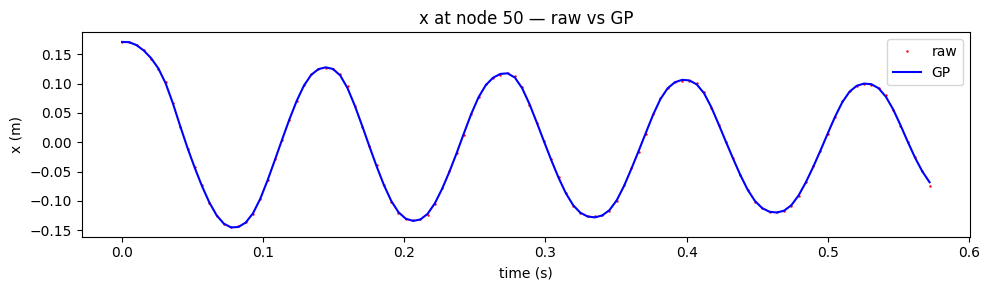

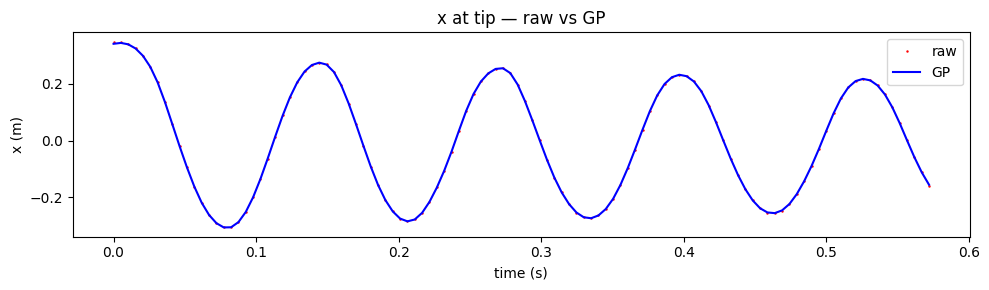

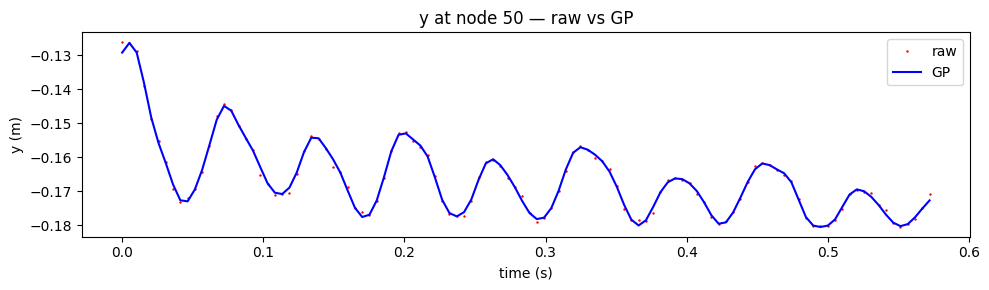

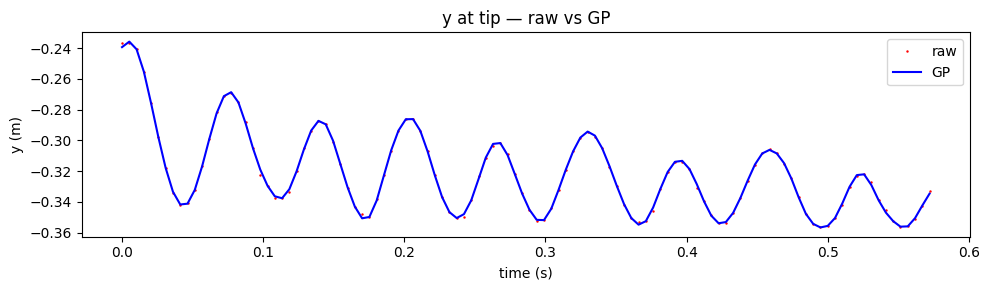

In [663]:
import matplotlib.pyplot as plt
# Compare raw vs GP at the same spatial column (arc position) — midpoint node is a good representative
# 
mid = N_TRAIN_PTS // 2  # midpoint node — auto-scales to N_TRAIN_PTS
plt.figure(figsize=(10, 3))
plt.plot(t_raw, x_train_all[:, mid], 'r.', ms=1.5, label='raw')
plt.plot(t_raw, x_gp_all[:, mid], 'b-', lw=1.5, label='GP')
plt.xlabel('time (s)')
plt.ylabel('x (m)')
plt.title(f'x at node {mid} — raw vs GP')
plt.legend()
plt.tight_layout()
plt.show()

# Also check the tip
plt.figure(figsize=(10, 3))
plt.plot(t_raw, x_train_all[:, -1], 'r.', ms=1.5, label='raw')
plt.plot(t_raw, x_gp_all[:, -1], 'b-', lw=1.5, label='GP')
plt.xlabel('time (s)')
plt.ylabel('x (m)')
plt.title('x at tip — raw vs GP')
plt.legend()
plt.tight_layout()
plt.show()

# Check y at the same nodes

mid = N_TRAIN_PTS // 2  # midpoint node
plt.figure(figsize=(10, 3))
plt.plot(t_raw, y_train_all[:, mid], 'r.', ms=1.5, label='raw')
plt.plot(t_raw, y_gp_all[:, mid], 'b-', lw=1.5, label='GP')
plt.xlabel('time (s)')
plt.ylabel('y (m)')
plt.title(f'y at node {mid} — raw vs GP')
plt.legend()
plt.tight_layout()
plt.show()

# Also check the tip
plt.figure(figsize=(10, 3))
plt.plot(t_raw, y_train_all[:, -1], 'r.', ms=1.5, label='raw')
plt.plot(t_raw, y_gp_all[:, -1], 'b-', lw=1.5, label='GP')
plt.xlabel('time (s)')
plt.ylabel('y (m)')
plt.title('y at tip — raw vs GP')
plt.legend()
plt.tight_layout()
plt.show()





## Step 4 — 3D surface: GP smoothed x(t, node)

In [664]:
import numpy as np
import plotly.graph_objects as go

# Subsample frames for speed (every 4th frame)
_stride = 1
_frames = np.arange(0, n_frames, _stride)
_n_pts  = N_TRAIN_PTS

# Build grids using physical GP positions — same layout as raw data surface
X_grid_gp = x_gp_all[_frames, :].T                        # (n_pts, n_t)  GP horizontal position
T_grid_gp = np.tile(t_raw[_frames], (_n_pts, 1))           # (n_pts, n_t)  time
Y_grid_gp = y_gp_all[_frames, :].T                        # (n_pts, n_t)  GP vertical position

# ── Plotly 3D surface: GP smoothed x vs y (horizontal position on y-axis) ─
fig3d = go.Figure(go.Surface(
    x=T_grid_gp,
    y=X_grid_gp,
    z=Y_grid_gp,
    colorscale='viridis',
    colorbar=dict(title='y (m)'),
))
fig3d.update_layout(
    title='Rod deformation surface (GP smoothed)',
    scene=dict(
        xaxis_title='time (s)',
        yaxis_title='horizontal x (m)',
        zaxis_title='vertical y (m)',
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.8))
    ),
    width=750, height=550, margin=dict(l=0, r=0, t=40, b=0)
)
fig3d.show()


## Step 4 — 3D surface: GP smoothed y(t, node)

In [665]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Subsample frames for speed
_stride = 1
_frames = np.arange(0, n_frames, _stride)

# Raw data grids (100-pt video nodes)
_n_raw = N_VIDEO_PTS
X_raw = x_m[_frames, :].T
T_raw = np.tile(t_raw[_frames], (_n_raw, 1))
Y_raw = y_m[_frames, :].T

# GP data grids (N_TRAIN_PTS GP nodes, physical coordinates)
_n_gp = N_TRAIN_PTS
X_gp  = x_gp_all[_frames, :].T
T_gp  = np.tile(t_raw[_frames], (_n_gp, 1))
Y_gp  = y_gp_all[_frames, :].T

# ── Side-by-side subplots ──────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=['Raw data', 'GP smoothed'],
    horizontal_spacing=0.05,
)
fig.add_trace(go.Surface(x=T_raw, y=X_raw, z=Y_raw,
                          colorscale='viridis', showscale=False), row=1, col=1)
fig.add_trace(go.Surface(x=T_gp,  y=X_gp,  z=Y_gp,
                          colorscale='viridis', showscale=True,
                          colorbar=dict(title='y (m)', x=1.02)), row=1, col=2)

_cam = dict(eye=dict(x=1.5, y=-1.5, z=0.8))
_ax  = dict(xaxis_title='time (s)', yaxis_title='horizontal x (m)', zaxis_title='vertical y (m)')
fig.update_layout(
    title='Rod deformation surface — Raw vs GP smoothed',
    scene=dict(camera=_cam, **_ax),
    scene2=dict(camera=_cam, **_ax),
    width=1200, height=550, margin=dict(l=0, r=60, t=50, b=0)
)
fig.show()


## Step 8 — Compute conjugate momenta

From the Hamiltonian structure (verified in `verlet_step`):

```
dx/dt     = p_x / (ρA)    →   p_x   = ρA · ẋ
dy/dt     = p_y / (ρA)    →   p_y   = ρA · ẏ
dθ/dt     = p_θ / (ρI)    →   p_θ   = ρI · θ̇
```

These are momentum per unit length (linear) and angular momentum per unit length.

p_x   range: [-1.1902e+00, 1.1333e+00]
p_y   range: [-4.5401e-01, 3.1168e-01]
p_θ   range: [-2.6650e-05, 2.8694e-05]
p_x_dot   range: [-5.6656e+01, 5.3147e+01]
p_y_dot   range: [-3.3296e+01, 2.9514e+01]
p_θ_dot   range: [-2.8967e-03, 1.9076e-03]

ρA = 7.8540e-02  ρI = 4.9087e-07


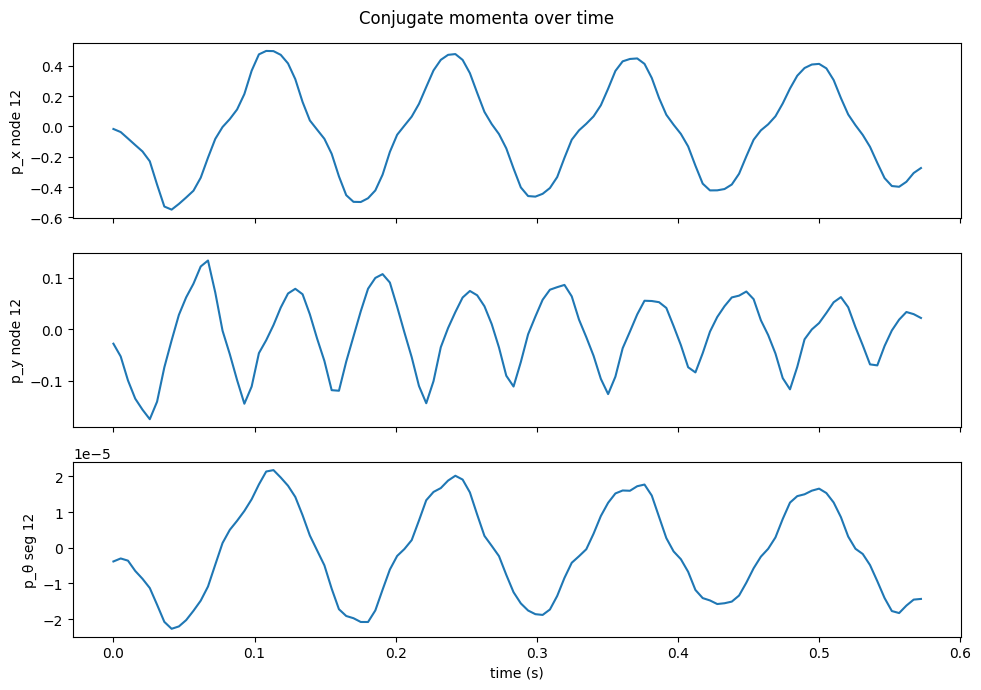

In [666]:
p_x     = rho * A * xdot       # (n_frames, N+1)
p_y     = rho * A * ydot       # (n_frames, N+1)
p_theta = rho * I * thetadot   # (n_frames, N)

# Clamp boundary: base node momenta are zero
p_x[:, 0]     = 0.0
p_y[:, 0]     = 0.0
# p_theta has N segments; segment 0 is at the clamped end
p_theta[:, 0] = 0.0

# ── Time derivatives of momenta (for z_dot) ───────────────────────────────
dt = 1.0 / FPS
p_x_dot     = np.gradient(p_x,     dt, axis=0)  # (n_frames, N+1)
p_y_dot     = np.gradient(p_y,     dt, axis=0)  # (n_frames, N+1)
p_theta_dot = np.gradient(p_theta, dt, axis=0)  # (n_frames, N)

# Enforce zero acceleration at the clamped node
p_x_dot[:, 0]     = 0.0
p_y_dot[:, 0]     = 0.0
p_theta_dot[:, 0] = 0.0

print(f'p_x   range: [{p_x.min():.4e}, {p_x.max():.4e}]')
print(f'p_y   range: [{p_y.min():.4e}, {p_y.max():.4e}]')
print(f'p_θ   range: [{p_theta.min():.4e}, {p_theta.max():.4e}]')
print(f'p_x_dot   range: [{p_x_dot.min():.4e}, {p_x_dot.max():.4e}]')
print(f'p_y_dot   range: [{p_y_dot.min():.4e}, {p_y_dot.max():.4e}]')
print(f'p_θ_dot   range: [{p_theta_dot.min():.4e}, {p_theta_dot.max():.4e}]')

# Compare orders of magnitude to simulation
print(f'\nρA = {rho*A:.4e}  ρI = {rho*I:.4e}')

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, dpi=100)
node = N // 2
axes[0].plot(t_raw, p_x[:, node])
axes[0].set_ylabel(f'p_x node {node}')
axes[1].plot(t_raw, p_y[:, node])
axes[1].set_ylabel(f'p_y node {node}')
axes[2].plot(t_raw, p_theta[:, node])
axes[2].set_ylabel(f'p_θ seg {node}')
axes[2].set_xlabel('time (s)')
fig.suptitle('Conjugate momenta over time')
plt.tight_layout()
plt.show()

## Time derivatives of momenta: ṗ_x, ṗ_y, ṗ_θ 

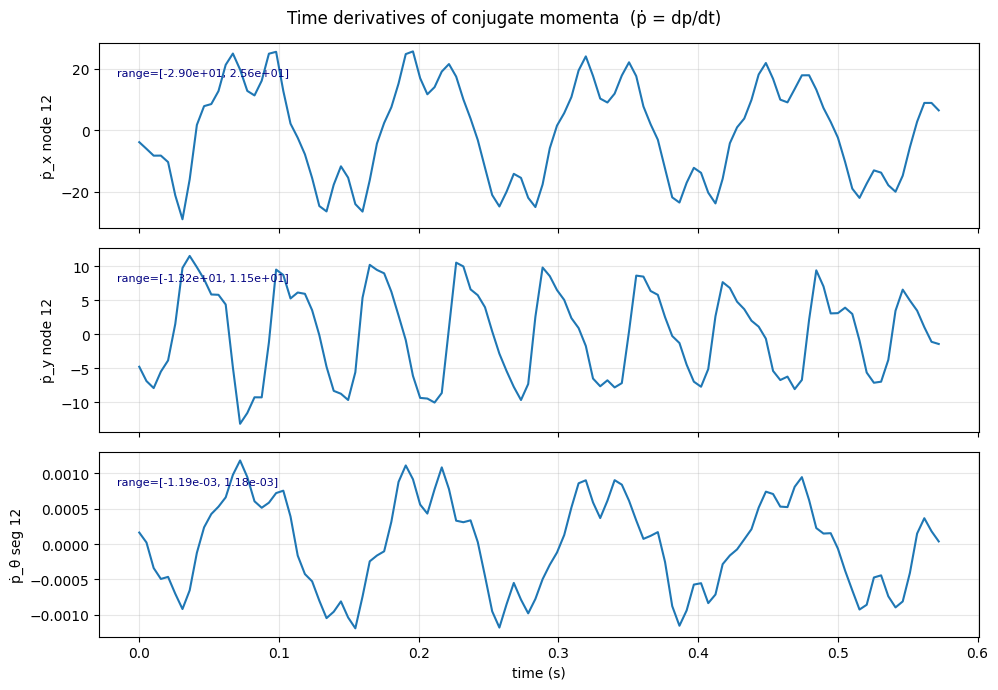

In [667]:
# ── Time derivatives of momenta: ṗ_x, ṗ_y, ṗ_θ ──────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, dpi=100)
node = N // 2

axes[0].plot(t_raw, p_x_dot[:, node])
axes[0].set_ylabel(f'ṗ_x node {node}')
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f'range=[{p_x_dot[:,node].min():.2e}, {p_x_dot[:,node].max():.2e}]',
                 xy=(0.02, 0.82), xycoords='axes fraction', fontsize=8, color='navy')

axes[1].plot(t_raw, p_y_dot[:, node])
axes[1].set_ylabel(f'ṗ_y node {node}')
axes[1].grid(True, alpha=0.3)
axes[1].annotate(f'range=[{p_y_dot[:,node].min():.2e}, {p_y_dot[:,node].max():.2e}]',
                 xy=(0.02, 0.82), xycoords='axes fraction', fontsize=8, color='navy')

axes[2].plot(t_raw, p_theta_dot[:, node])
axes[2].set_ylabel(f'ṗ_θ seg {node}')
axes[2].set_xlabel('time (s)')
axes[2].grid(True, alpha=0.3)
axes[2].annotate(f'range=[{p_theta_dot[:,node].min():.2e}, {p_theta_dot[:,node].max():.2e}]',
                 xy=(0.02, 0.82), xycoords='axes fraction', fontsize=8, color='navy')

fig.suptitle('Time derivatives of conjugate momenta  (ṗ = dp/dt)')
plt.tight_layout()
plt.show()

## Step 9 — Assemble state matrix z

The simulation stores a row per time step:

```
z[k, :] = [x (N+1),  y (N+1),  θ (N),  p_x (N+1),  p_y (N+1),  p_θ (N)]
```

Total columns = 4(N+1) + 2N = 6N + 4 = 154 for N=25.

In [668]:
# Assemble z row by row matching the simulation layout
z = np.hstack([
    x_smooth,       # columns 0      .. N       (N+1 cols)
    y_smooth,       # columns N+1    .. 2N+1    (N+1 cols)
    theta_smooth,   # columns 2N+2   .. 3N+1    (N   cols)
    p_x,            # columns 3N+2   .. 4N+2    (N+1 cols)
    p_y,            # columns 4N+3   .. 5N+3    (N+1 cols)
    p_theta,        # columns 5N+4   .. 6N+3    (N   cols)
])

# Assemble z_dot — time derivative of every state, same column layout as z
z_dot = np.hstack([
    xdot,           # columns 0      .. N       (N+1 cols)
    ydot,           # columns N+1    .. 2N+1    (N+1 cols)
    thetadot,       # columns 2N+2   .. 3N+1    (N   cols)
    p_x_dot,        # columns 3N+2   .. 4N+2    (N+1 cols)
    p_y_dot,        # columns 4N+3   .. 5N+3    (N+1 cols)
    p_theta_dot,    # columns 5N+4   .. 6N+3    (N   cols)
])

expected_cols = 4*(N+1) + 2*N   # = 6N+4 = 154 for N=25
assert z.shape     == (n_frames, expected_cols), f'z shape {z.shape} != expected ({n_frames}, {expected_cols})'
assert z_dot.shape == (n_frames, expected_cols), f'z_dot shape {z_dot.shape} != expected ({n_frames}, {expected_cols})'

t_out = t_raw.copy()

print(f'z shape:     {z.shape}  (time steps × state dim)')
print(f'z_dot shape: {z_dot.shape}  (same layout — time derivatives)')
print(f't shape:     {t_out.shape}')
print(f'State dim breakdown: 4×{N+1} + 2×{N} = {expected_cols}')
print()
print('Column index check (same for z and z_dot):')
print(f'  x  / ẋ:        0 … {N}')
print(f'  y  / ẏ:        {N+1} … {2*(N+1)-1}')
print(f'  θ  / θ̇:        {2*(N+1)} … {2*(N+1)+N-1}')
print(f'  p_x / ṗ_x:    {2*(N+1)+N} … {3*(N+1)+N-1}')
print(f'  p_y / ṗ_y:    {3*(N+1)+N} … {4*(N+1)+N-1}')
print(f'  p_θ / ṗ_θ:    {4*(N+1)+N} … {4*(N+1)+2*N-1}')

z shape:     (112, 154)  (time steps × state dim)
z_dot shape: (112, 154)  (same layout — time derivatives)
t shape:     (112,)
State dim breakdown: 4×26 + 2×25 = 154

Column index check (same for z and z_dot):
  x  / ẋ:        0 … 25
  y  / ẏ:        26 … 51
  θ  / θ̇:        52 … 76
  p_x / ṗ_x:    77 … 102
  p_y / ṗ_y:    103 … 128
  p_θ / ṗ_θ:    129 … 153


## Step 10 — Sanity checks

Cross-check the reconstructed states before saving:
1. **Boundary condition** — node 0 should be fixed at (0, 0) with zero momentum
2. **Arc-length conservation** — rod is inextensible; arc length should stay ≈ L0
3. **Kinetic energy** — should be non-negative and physically plausible
4. **Consistency** — ẋ recovered from p_x should match original differentiation

=== Boundary conditions ===
max |x[:,0]|     = 0.00e+00  (expect 0)
max |y[:,0]|     = 0.00e+00  (expect 0)
max |p_x[:,0]|   = 0.00e+00  (expect 0)
max |p_y[:,0]|   = 0.00e+00  (expect 0)

=== Arc-length conservation ===
Arc length: mean=0.3699 m  std=0.0118 m  max_err=0.0420 m

=== Kinetic energy (approximate) ===
KE range: [1.0369e-02, 7.8054e+01] J/m
KE < 0:   0 frames  (expect 0)


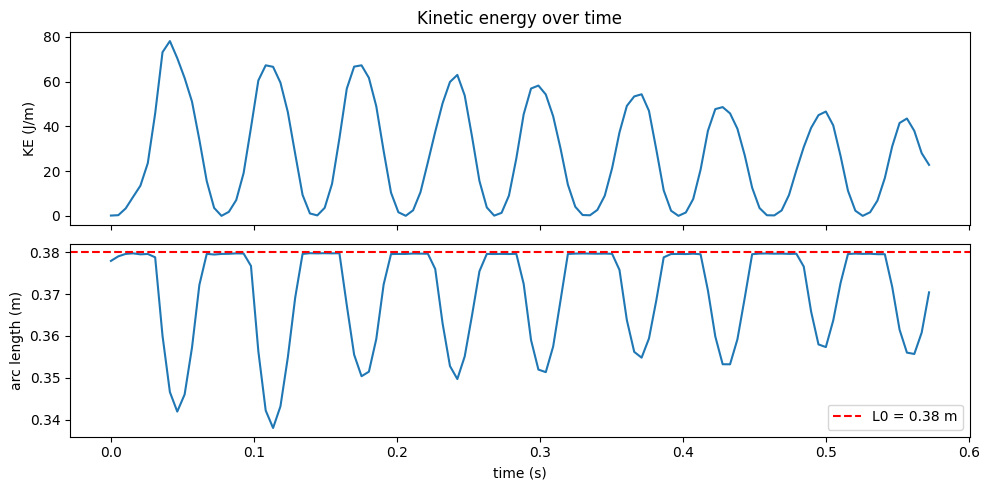


=== Consistency: p_x/rho/A vs ẋ ===
max |p_x/(ρA) - ẋ| = 1.78e-15  (should be ~0)


In [669]:
print('=== Boundary conditions ===')
print(f'max |x[:,0]|     = {np.abs(z[:, 0]).max():.2e}  (expect 0)')
print(f'max |y[:,0]|     = {np.abs(z[:, N+1]).max():.2e}  (expect 0)')
print(f'max |p_x[:,0]|   = {np.abs(z[:, 2*(N+1)+N]).max():.2e}  (expect 0)')
print(f'max |p_y[:,0]|   = {np.abs(z[:, 3*(N+1)+N]).max():.2e}  (expect 0)')

print('\n=== Arc-length conservation ===')
x_check = z[:, :N+1]
y_check = z[:, N+1:2*(N+1)]
arc = np.sqrt(np.diff(x_check, axis=1)**2 + np.diff(y_check, axis=1)**2).sum(axis=1)
print(f'Arc length: mean={arc.mean():.4f} m  std={arc.std():.4f} m  max_err={np.abs(arc-L0).max():.4f} m')

print('\n=== Kinetic energy (approximate) ===')
px_check = z[:, 2*(N+1)+N : 3*(N+1)+N]
py_check = z[:, 3*(N+1)+N : 4*(N+1)+N]
pt_check = z[:, 4*(N+1)+N :]
KE_lin = (1/(2*rho*A)) * (px_check**2 + py_check**2).sum(axis=1)
KE_rot = (1/(2*rho*I)) * (pt_check**2).sum(axis=1)
KE = KE_lin + KE_rot
print(f'KE range: [{KE.min():.4e}, {KE.max():.4e}] J/m')
print(f'KE < 0:   {(KE < 0).sum()} frames  (expect 0)')

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, dpi=100)
axes[0].plot(t_out, KE)
axes[0].set_ylabel('KE (J/m)')
axes[0].set_title('Kinetic energy over time')
axes[1].plot(t_out, arc)
axes[1].axhline(L0, color='r', ls='--', label=f'L0 = {L0} m')
axes[1].set_ylabel('arc length (m)')
axes[1].set_xlabel('time (s)')
axes[1].legend()
plt.tight_layout()
plt.show()

print('\n=== Consistency: p_x/rho/A vs ẋ ===')
xdot_from_p = px_check / (rho * A)
err = np.abs(xdot_from_p - xdot).max()
print(f'max |p_x/(ρA) - ẋ| = {err:.2e}  (should be ~0)')

## Step 11 — Visual comparison: real vs simulation shape

Plot the real data rod shapes alongside what the simulation produces,
to check the coordinate system and scale are consistent.

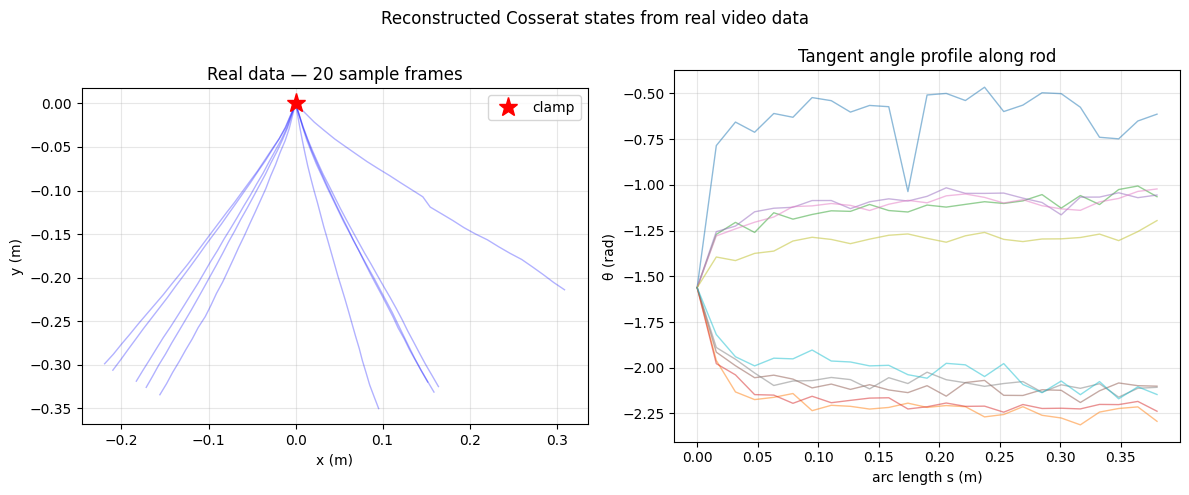

In [673]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

# Left: real data — rod shapes over time
ax = axes[0]
for i in np.linspace(0, n_frames-1, 10, dtype=int):
    xi = z[i, :N+1]
    yi = z[i, N+1:2*(N+1)]
    ax.plot(xi, yi, 'b', alpha=0.3, lw=1)
ax.plot(0, 0, 'r*', ms=14, label='clamp')
ax.set_aspect('equal')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Real data — 20 sample frames')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: θ profile along arc at a few time steps
ax = axes[1]
s_nodes = np.linspace(0, L0, N)
for i in np.linspace(0, n_frames-1, 10, dtype=int):
    ax.plot(s_nodes, z[i, 2*(N+1):2*(N+1)+N], alpha=0.5, lw=1)
ax.set_xlabel('arc length s (m)')
ax.set_ylabel('θ (rad)')
ax.set_title('Tangent angle profile along rod')
ax.grid(True, alpha=0.3)

plt.suptitle('Reconstructed Cosserat states from real video data')
plt.tight_layout()
plt.show()

## Step 12 — Save to .mat

Saves a file compatible with `cosserat_GPR_pipeline.m`.
The MATLAB pipeline reads: `data.z`, `data.t`, `data.N`, `data.L0`,
`data.rho`, `data.E`, `data.A`, `data.G`, `data.I`.

We also save `pixels_per_metre` and `fps` for traceability.

In [672]:
os.makedirs(os.path.dirname(OUTPUT_MAT), exist_ok=True)

# ── File 1: cosserat_real_data.mat — state vector z ──────────────────────
save_dict_z = {
    'z':                 z,
    't':                 t_out.reshape(-1, 1),
    'N':                 float(N),
    'L0':                L0,
    'rho':               rho,
    'E':                 E,
    'A':                 A,
    'G':                 G,
    'I':                 I,
    'D':                 float(expected_cols),
    'fps':               FPS,
    'pixels_per_metre':  float(scale),  # actual value used (from auto-calib or config)
    'sg_window':         float(SG_WINDOW),
    'sg_poly':           float(SG_POLY),
}
sio.savemat(OUTPUT_MAT, save_dict_z)
print(f'Saved: {OUTPUT_MAT}')
print(f'  z:   {z.shape}  (time steps × state dim)')

# ── File 2: cosserat_real_data_dot.mat — state derivative z_dot ──────────
save_dict_zdot = {
    'z_dot':             z_dot,
    't':                 t_out.reshape(-1, 1),
    'N':                 float(N),
    'L0':                L0,
    'rho':               rho,
    'E':                 E,
    'A':                 A,
    'G':                 G,
    'I':                 I,
    'D':                 float(expected_cols),
    'fps':               FPS,
    'pixels_per_metre':  float(scale),  # actual value used (from auto-calib or config)
    'sg_window':         float(SG_WINDOW),
    'sg_poly':           float(SG_POLY),
}
sio.savemat(OUTPUT_MAT_DOT, save_dict_zdot)
print(f'Saved: {OUTPUT_MAT_DOT}')
print(f'  z_dot: {z_dot.shape}  (time steps × state dim — derivatives)')

print(f'\nt: {t_out.shape}  from {t_out[0]:.4f} s to {t_out[-1]:.4f} s')
print(f'N={int(N)}, L0={L0}, rho={rho}, E={E:.2e}, A={A:.4e}, I={I:.4e}')

FileNotFoundError: [Errno 2] No such file or directory: ''

## Notes & known limitations

### What to verify before feeding into the GPR pipeline

1. **`PIXELS_PER_METRE`** — the most critical parameter. Measure it from a
   known physical length visible in the video (rod at rest, ruler, etc.).
   The arc-length check in Step 3 should show mean ≈ L0 = 0.5 m.

2. **Smoothing window** — if derivatives look spiky, increase `SG_WINDOW`.
   If real dynamics are being lost, decrease it.

3. **Kinetic energy** — should peak during fast motion and decay after the rod
   settles. Unphysically large values indicate scale or derivative issues.

4. **Arc-length** — the real rod is approximately inextensible. If arc length
   drifts significantly from L0, the skeletonization or resampling has issues.

### Known limitations

- **p_theta sign convention** — verified against `verlet_step` line 268:
  `dtheta_dt = p_theta/(rho*I)` → `p_theta = rho*I * theta_dot`. This is **multiply**, not divide.

- **Inextensibility** — the simulation enforces inextensibility through the
  constitutive law, not as a hard constraint. The reconstructed x, y from video
  may not be exactly inextensible; this is expected.

- **Missing deltaH** — the simulation `.mat` also contains `deltaH`, `v1`, `n_x`,
  etc. (internal forces). These cannot be recovered from video alone and are not
  included here. The GPR pipeline only strictly requires `z`, `t`, `N`, `L0`.